# Post 08: How Do Equilibrium Samples Become Free Energies?

This notebook is the presentation layer for the eighth tutorial. The reusable PMF, reweighting, RDF-PMF, and figure logic lives in `src/kups_md_tutorials/`.


In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.figures import generate_post08_figures
from kups_md_tutorials.free_energies import load_free_energy_summary

## Configuration

The smoke and full profiles sample a known double-well equilibrium distribution and compare histogram PMFs, bootstrap uncertainty, reweighting, and an RDF-derived PMF.

In [3]:
for profile in ["smoke", "full"]:
    print(f"--- {profile} ---")
    print(json.dumps(json.loads(Path(f"configs/post-08/{profile}.json").read_text()), indent=2))

--- smoke ---
{
  "post": "08",
  "profile": "smoke",
  "title": "How Do Equilibrium Samples Become Free Energies?",
  "free_energy_experiment": {
    "temperature": 1.0,
    "sample_count": 12000,
    "seed": 2026071408,
    "domain_min": -2.5,
    "domain_max": 2.5,
    "grid_points": 801,
    "bin_widths": [
      0.1,
      0.25
    ],
    "bootstrap_replicates": 80,
    "bias_center": 0.9,
    "bias_strength": 2.0,
    "rdf_peak_radius": 1.2,
    "rdf_peak_width": 0.16
  }
}
--- full ---
{
  "post": "08",
  "profile": "full",
  "title": "How Do Equilibrium Samples Become Free Energies?",
  "free_energy_experiment": {
    "temperature": 1.0,
    "sample_count": 80000,
    "seed": 2026071408,
    "domain_min": -2.5,
    "domain_max": 2.5,
    "grid_points": 1201,
    "bin_widths": [
      0.06,
      0.18,
      0.35
    ],
    "bootstrap_replicates": 160,
    "bias_center": 0.9,
    "bias_strength": 2.0,
    "rdf_peak_radius": 1.2,
    "rdf_peak_width": 0.16
  }
}


## Committed Results

The summary reports barrier estimates for each bin width, bootstrap standard errors, a reweighted barrier, and RDF-PMF diagnostics.

In [4]:
summary = load_free_energy_summary(Path("results/post-08/full/free_energy_summary.json"))
print("true barrier=", round(summary.true_barrier_height, 4))
for item in summary.bins:
    print("bin", item.bin_width, "barrier=", round(item.barrier_height, 4), "+/-", round(item.bootstrap_barrier_standard_error, 4), "rmse=", round(item.rmse_vs_true, 4))
print("reweighted barrier=", round(summary.reweighted_barrier_height, 4))

true barrier= 1.0
bin 0.06 barrier= 0.9854 +/- 0.032 rmse= 0.1707
bin 0.18 barrier= 0.9761 +/- 0.0166 rmse= 0.3665
bin 0.35 barrier= 0.9152 +/- 0.0174 rmse= 0.5906
reweighted barrier= 1.1229


## Figure

The full-profile figure is regenerated from committed compact outputs.

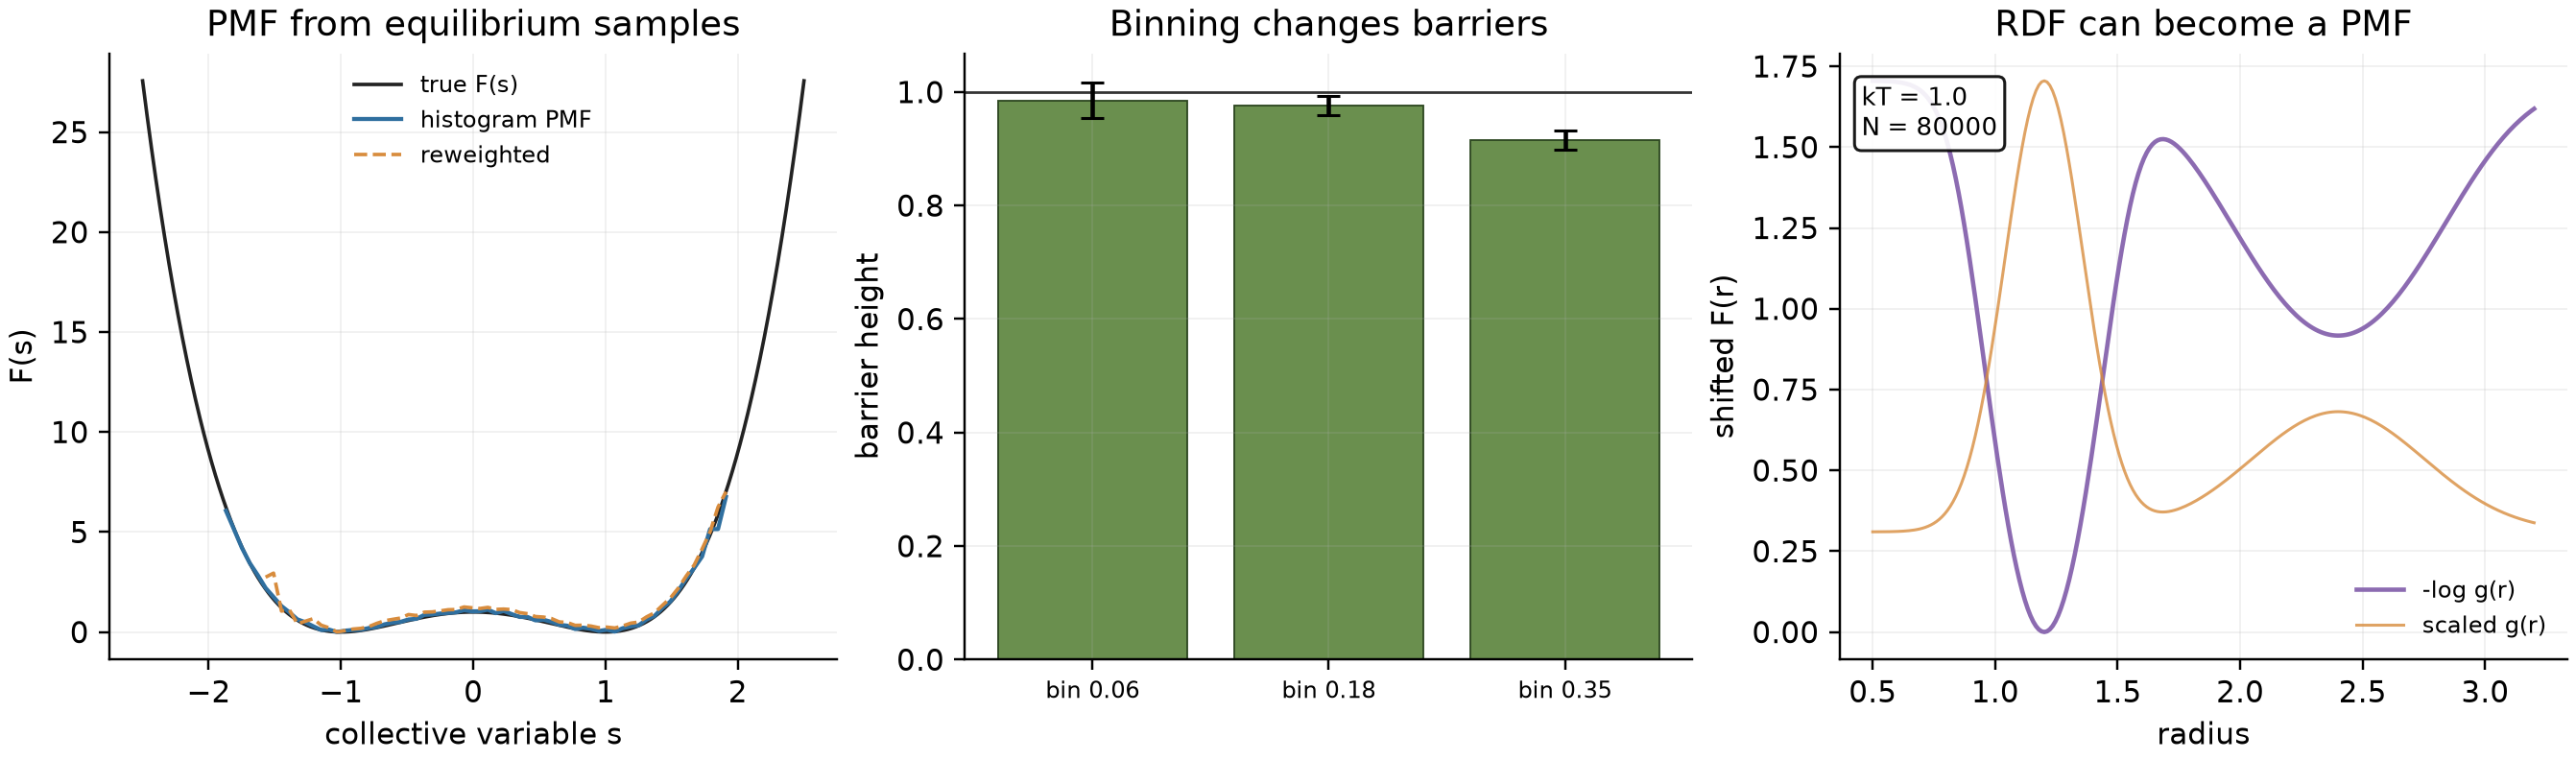

In [5]:
generate_post08_figures(
    result_dir=Path("results/post-08/full"),
    figure_dir=Path("figures/post-08"),
    snapshot_dir=Path("snapshots/post-08"),
    name="free_energy_diagnostics_full",
)
display(Image(filename="figures/post-08/free_energy_diagnostics_full.png"))